Notebook 6: Improved Model Retraining
============================================================
Sequential Transfer Learning for Medicinal Plant Identification
Student: Hari (3146279) | BSc Software Engineering | University of Stirling

This notebook retrains the model with significant improvements:
- EfficientNetB3 backbone (better than ResNet50 for small datasets)
- Stronger data augmentation
- Class weighting for imbalanced data
- Cosine annealing learning rate
- Gradual unfreezing strategy
- Drops impossible classes (Trifolium=1img, Ziziphus=0img)

Run in Google Colab with GPU runtime!
Runtime -> Change runtime type -> GPU


Cell 1 - Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted")

Mounted at /content/drive
Drive mounted


## Imports

In [ ]:
import os
import json
import zipfile
import shutil
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, LearningRateScheduler
)
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print(f"TensorFlow: {tf.__version__}")

# GPU check
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU: {gpus[0].name}")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("WARNING: No GPU detected! Training will be very slow.")
    print("Go to: Runtime -> Change runtime type -> GPU")

TensorFlow: 2.19.0
GPU: /physical_device:GPU:0


## Configuration

In [ ]:
IMG_SIZE = (300, 300)  # EfficientNetB3 uses 300x300 (vs ResNet50's 224x224)
BATCH_SIZE = 16  # Smaller batch = better generalization on small datasets
EPOCHS_FROZEN = 10  # Phase 1: train head only
EPOCHS_UNFROZEN = 25  # Phase 2: fine-tune with unfrozen layers
SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

# Paths
DRIVE_BASE = "/content/drive/MyDrive"
PROJECT_DIR = os.path.join(DRIVE_BASE, "MedicinalPlant_Dissertation")
DATA_DIR = os.path.join(PROJECT_DIR, "data")
MODEL_DIR = os.path.join(PROJECT_DIR, "models")
os.makedirs(MODEL_DIR, exist_ok=True)

# Classes to DROP (impossible to learn from 0-1 images)
DROP_CLASSES = ['Trifolium Repens', 'Trifolium_Repens', 'Ziziphus mauritiana', 'Ziziphus_mauritiana']

print(f"Project dir: {PROJECT_DIR}")
print(f"Image size: {IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Training: {EPOCHS_FROZEN} frozen + {EPOCHS_UNFROZEN} unfrozen epochs")

Project dir: /content/drive/MyDrive/MedicinalPlant_Dissertation
Image size: (300, 300)
Batch size: 16
Training: 10 frozen + 25 unfrozen epochs


## Find and load Dataset 5 (SIMPD Commercial)

In [ ]:
def find_image_directory(base_dir):
    """Walk directory tree to find the folder containing class subdirectories with images."""
    if not os.path.exists(base_dir):
        return None
    for root, dirs, files in os.walk(base_dir):
        dirs[:] = [d for d in dirs if not d.startswith('.')]
        if not dirs:
            continue
        sample_dir = os.path.join(root, dirs[0])
        if os.path.isdir(sample_dir):
            sample_files = os.listdir(sample_dir)
            has_images = any(f.lower().endswith(('.jpg', '.jpeg', '.png')) for f in sample_files)
            if has_images:
                return root
    return None

print(">>> Finding Dataset 5 (SIMPD Commercial)...")

# Try multiple possible locations
dataset_path = None
possible_paths = [
    os.path.join(DATA_DIR, "dataset5"),
    os.path.join(DATA_DIR, "Dataset 5"),
    os.path.join(DATA_DIR, "SIMPD"),
    os.path.join(DATA_DIR, "dataset5_commercial"),
]

# Check config file first
config_path = os.path.join(PROJECT_DIR, "dataset_config.json")
if os.path.exists(config_path):
    with open(config_path, 'r') as f:
        config = json.load(f)
    ds5 = config.get("dataset_paths", {}).get("dataset5")
    if ds5:
        possible_paths.insert(0, ds5)

for p in possible_paths:
    if os.path.exists(p):
        found = find_image_directory(p)
        if found:
            dataset_path = found
            break

# Extract zip if needed
if dataset_path is None:
    for zname in ["dataset5.zip", "Dataset 5.zip", "SIMPD.zip"]:
        zip_path = os.path.join(DATA_DIR, zname)
        if os.path.exists(zip_path):
            print(f"  Extracting {zname}...")
            extract_to = os.path.join(DATA_DIR, "dataset5")
            os.makedirs(extract_to, exist_ok=True)
            with zipfile.ZipFile(zip_path, 'r') as z:
                z.extractall(extract_to)
            # Handle nested zips
            for root, dirs, files in os.walk(extract_to):
                for f in files:
                    if f.endswith('.zip'):
                        nested = os.path.join(root, f)
                        print(f"    Nested zip: {f}")
                        with zipfile.ZipFile(nested, 'r') as z:
                            z.extractall(root)
                        os.remove(nested)
            dataset_path = find_image_directory(extract_to)
            break

if dataset_path is None:
    # Last resort - search entire data directory
    print("  Searching entire data directory...")
    dataset_path = find_image_directory(DATA_DIR)

if dataset_path is None:
    raise FileNotFoundError(
        "Could not find Dataset 5!\n"
        "Please make sure your dataset is in Google Drive at:\n"
        f"  {DATA_DIR}/dataset5/\n"
        "Each species should be in its own subdirectory."
    )

print(f"\n>>> Dataset found: {dataset_path}")

# List classes
all_classes = sorted([
    d for d in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, d)) and not d.startswith('.')
])

# Drop impossible classes
keep_classes = [c for c in all_classes if c not in DROP_CLASSES]
dropped = [c for c in all_classes if c in DROP_CLASSES]

print(f"\nAll classes found: {len(all_classes)}")
if dropped:
    print(f"DROPPING {len(dropped)} classes (too few images): {dropped}")
print(f"Keeping {len(keep_classes)} classes:")

# Count images per class
for c in keep_classes:
    class_dir = os.path.join(dataset_path, c)
    n_images = len([f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    print(f"  {c:35s} {n_images:4d} images")

NUM_CLASSES = len(keep_classes)

>>> Finding Dataset 5 (SIMPD Commercial)...

>>> Dataset found: /content/drive/MyDrive/MedicinalPlant_Dissertation/data/dataset5/SIMPD V1 South Indian Medicinal Plants dataset (Version 1)

All classes found: 20
DROPPING 2 classes (too few images): ['Trifolium Repens', 'Ziziphus mauritiana']
Keeping 18 classes:
  Abutilon Indicum                     165 images
  Aloe barbadensis miller              145 images
  Calotropis gigantea                  106 images
  Canna indica                         149 images
  Cissus quadrangularis                134 images
  Curcuma longa                        110 images
  Eclipta prostrate                    208 images
  Eichhornia Crassipes                 202 images
  Hibiscus Rosasinensis                113 images
  Ixora coccinea                       114 images
  Justica adhatoda                     100 images
  Murraya koenigii                     118 images
  Ocimum tenuiflorum                   102 images
  Ouretlanata                         

## Create filtered dataset (excluding dropped classes)

In [ ]:
# If we need to drop classes, copy to a temp directory without them
if dropped:
    filtered_path = "/content/filtered_dataset"
    if os.path.exists(filtered_path):
        shutil.rmtree(filtered_path)
    os.makedirs(filtered_path)
    for c in keep_classes:
        src = os.path.join(dataset_path, c)
        dst = os.path.join(filtered_path, c)
        shutil.copytree(src, dst)
    dataset_path = filtered_path
    print(f"\n>>> Created filtered dataset at {filtered_path}")
else:
    print(">>> No classes to drop, using original dataset")


>>> Created filtered dataset at /content/filtered_dataset


## Load data with stratified train/val split

In [ ]:
print(f"\n>>> Loading dataset ({NUM_CLASSES} species)...")

train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

class_names = train_dataset.class_names
print(f"\nClasses: {class_names}")
print(f"Number of classes: {len(class_names)}")


>>> Loading dataset (18 species)...
Found 2313 files belonging to 18 classes.
Using 1851 files for training.
Found 2313 files belonging to 18 classes.
Using 462 files for validation.

Classes: ['Abutilon Indicum', 'Aloe barbadensis miller', 'Calotropis gigantea', 'Canna indica', 'Cissus quadrangularis', 'Curcuma longa', 'Eclipta prostrate', 'Eichhornia Crassipes', 'Hibiscus Rosasinensis', 'Ixora coccinea', 'Justica adhatoda', 'Murraya koenigii', 'Ocimum tenuiflorum', 'Ouretlanata', 'Phyllanthus amarus', 'Ricinus communis', 'Senna Atriculata', 'Sesbania grandiflora']
Number of classes: 18


## Compute class weights for imbalanced data

In [ ]:
print("\n>>> Computing class weights...")

# Count images per class
class_counts = {}
for c in class_names:
    class_dir = os.path.join(dataset_path, c)
    class_counts[c] = len([f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

total = sum(class_counts.values())
n_classes = len(class_counts)

# Inverse frequency weighting
class_weight = {}
for i, c in enumerate(class_names):
    class_weight[i] = total / (n_classes * class_counts[c])

print("Class weights (higher = rarer, gets more attention):")
for i, c in enumerate(class_names):
    print(f"  {c:35s} count={class_counts[c]:4d}  weight={class_weight[i]:.3f}")


>>> Computing class weights...
Class weights (higher = rarer, gets more attention):
  Abutilon Indicum                    count= 165  weight=0.779
  Aloe barbadensis miller             count= 145  weight=0.886
  Calotropis gigantea                 count= 106  weight=1.212
  Canna indica                        count= 149  weight=0.862
  Cissus quadrangularis               count= 134  weight=0.959
  Curcuma longa                       count= 110  weight=1.168
  Eclipta prostrate                   count= 208  weight=0.618
  Eichhornia Crassipes                count= 202  weight=0.636
  Hibiscus Rosasinensis               count= 113  weight=1.137
  Ixora coccinea                      count= 114  weight=1.127
  Justica adhatoda                    count= 100  weight=1.285
  Murraya koenigii                    count= 118  weight=1.089
  Ocimum tenuiflorum                  count= 102  weight=1.260
  Ouretlanata                         count= 119  weight=1.080
  Phyllanthus amarus             

## Preprocessing

In [ ]:
# EfficientNet has its own preprocessing built-in (scales to [-1, 1])
# We apply it via the model's preprocessing layer, NOT as a dataset transform
# This means we feed raw 0-255 images to the model

AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)

print(">>> Datasets cached and prefetched")
print(">>> NOTE: EfficientNet preprocessing is applied inside the model")

>>> Datasets cached and prefetched
>>> NOTE: EfficientNet preprocessing is applied inside the model


## Build improved model

In [ ]:
print("\n>>> Building improved model...")
print("   Backbone: EfficientNetB3 (ImageNet)")
print(f"   Classes: {NUM_CLASSES}")

# Data augmentation - MUCH stronger than before
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomFlip("vertical"),
    layers.RandomRotation(0.2),  # ±36 degrees (was 0.1)
    layers.RandomZoom((-0.15, 0.15)),  # ±15% zoom (was 0.1)
    layers.RandomContrast(0.2),  # ±20% contrast (was 0.1)
    layers.RandomBrightness(0.15),  # ±15% brightness (NEW)
    layers.RandomTranslation(0.1, 0.1),  # ±10% shift (NEW)
], name="strong_augmentation")

# EfficientNetB3 base
base_model = EfficientNetB3(
    weights='imagenet',
    include_top=False,
    input_shape=(300, 300, 3)
)

# Freeze ALL layers initially (Phase 1: train head only)
base_model.trainable = False

# Build model
inputs = keras.Input(shape=(300, 300, 3))
x = data_augmentation(inputs)
# EfficientNet includes its own preprocessing (scales to [-1,1])
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(512, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = keras.Model(inputs, outputs, name="improved_plant_classifier")

print(f"\n>>> Model built!")
print(f"   Total params: {model.count_params():,}")
trainable = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
print(f"   Trainable params: {trainable:,} (head only)")
print(f"   Base frozen: {len(base_model.layers)} layers")


>>> Building improved model...
   Backbone: EfficientNetB3 (ImageNet)
   Classes: 18
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

>>> Model built!
   Total params: 11,715,649
   Trainable params: 927,506 (head only)
   Base frozen: 385 layers


## Phase 1: Train classification head (base frozen)

In [ ]:
print("\n" + "="*60)
print("PHASE 1: Training classification head (base frozen)")
print("="*60)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

callbacks_p1 = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-5,
        verbose=1
    )
]

history_p1 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS_FROZEN,
    callbacks=callbacks_p1,
    class_weight=class_weight,
    verbose=1
)

p1_val_acc = max(history_p1.history['val_accuracy'])
print(f"\n>>> Phase 1 best val accuracy: {p1_val_acc*100:.1f}%")


PHASE 1: Training classification head (base frozen)
Epoch 1/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 159s 1s/step - accuracy: 0.5192 - loss: 1.8078 - precision: 0.7074 - recall: 0.4151 - val_accuracy: 0.8896 - val_loss: 0.5942 - val_precision: 0.9810 - val_recall: 0.7814 - learning_rate: 0.0010
Epoch 2/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 21s 179ms/step - accuracy: 0.8543 - loss: 0.6171 - precision: 0.9050 - recall: 0.8187 - val_accuracy: 0.9242 - val_loss: 0.3934 - val_precision: 0.9595 - val_recall: 0.8723 - learning_rate: 0.0010
Epoch 3/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 21s 183ms/step - accuracy: 0.8981 - loss: 0.4686 - precision: 0.9275 - recall: 0.8674 - val_accuracy: 0.9264 - val_loss: 0.3253 - val_precision: 0.9297 - val_recall: 0.9156 - learning_rate: 0.0010
Epoch 4/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 22s 186ms/step - accuracy: 0.9055 - loss: 0.4267 - precision: 0.9270 - recall: 0.8748 - val_accuracy: 0.9762 - val_loss: 0.1879 - val_precision: 0.9804 - val_recall: 0.9740 - learning_rate: 0.0010
E

## Phase 2: Gradual unfreezing + fine-tuning

In [ ]:
print("\n" + "="*60)
print("PHASE 2: Fine-tuning with gradual unfreezing")
print("="*60)

# Unfreeze top layers of EfficientNetB3
base_model.trainable = True
total_layers = len(base_model.layers)
fine_tune_from = total_layers - 50  # Unfreeze last 50 layers

for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"   Base layers: {total_layers}")
print(f"   Unfrozen layers: {trainable_count}")
print(f"   Frozen layers: {total_layers - trainable_count}")

# Cosine annealing schedule
def cosine_schedule(epoch, lr):
    """Cosine annealing with warm restarts."""
    warmup = 3
    total = EPOCHS_UNFROZEN
    if epoch < warmup:
        return 1e-4 * (epoch + 1) / warmup  # Linear warmup
    else:
        progress = (epoch - warmup) / (total - warmup)
        return 1e-5 + 0.5 * (1e-4 - 1e-5) * (1 + np.cos(np.pi * progress))

# Compile with lower learning rate for fine-tuning
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

# Model save path
model_save_path = os.path.join(MODEL_DIR, "improved_model.keras")
model_h5_path = os.path.join(MODEL_DIR, "improved_model.h5")

callbacks_p2 = [
    ModelCheckpoint(
        model_save_path,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    LearningRateScheduler(cosine_schedule, verbose=1)
]

history_p2 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS_UNFROZEN,
    callbacks=callbacks_p2,
    class_weight=class_weight,
    verbose=1
)

p2_val_acc = max(history_p2.history['val_accuracy'])
print(f"\n>>> Phase 2 best val accuracy: {p2_val_acc*100:.1f}%")


PHASE 2: Fine-tuning with gradual unfreezing
   Base layers: 385
   Unfrozen layers: 50
   Frozen layers: 335

Epoch 1: LearningRateScheduler setting learning rate to 3.3333333333333335e-05.
Epoch 1/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.8049 - loss: 0.7624 - precision: 0.8488 - recall: 0.7730
Epoch 1: val_accuracy improved from -inf to 0.98268, saving model to /content/drive/MyDrive/MedicinalPlant_Dissertation/models/improved_model.keras
116/116 ━━━━━━━━━━━━━━━━━━━━ 61s 281ms/step - accuracy: 0.8051 - loss: 0.7615 - precision: 0.8491 - recall: 0.7733 - val_accuracy: 0.9827 - val_loss: 0.2019 - val_precision: 0.9847 - val_recall: 0.9762 - learning_rate: 3.3333e-05

Epoch 2: LearningRateScheduler setting learning rate to 6.666666666666667e-05.
Epoch 2/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.8756 - loss: 0.4892 - precision: 0.9027 - recall: 0.8595
Epoch 2: val_accuracy improved from 0.98268 to 0.98485, saving model to /content/drive/MyDrive/Medic

## Save model in multiple formats

In [ ]:
print("\n>>> Saving model...")

# Save .keras format
model.save(model_save_path)
print(f"  Saved: {model_save_path}")

# Save .h5 format
try:
    model.save(model_h5_path)
    print(f"  Saved: {model_h5_path}")
except Exception as e:
    print(f"  .h5 save failed (not critical): {e}")

# Save class names
class_names_path = os.path.join(MODEL_DIR, "improved_class_names.json")
with open(class_names_path, 'w') as f:
    json.dump(class_names, f)
print(f"  Saved: {class_names_path}")

# Save training history
history_combined = {}
for key in history_p1.history:
    history_combined[f"p1_{key}"] = [float(v) for v in history_p1.history[key]]
for key in history_p2.history:
    history_combined[f"p2_{key}"] = [float(v) for v in history_p2.history[key]]

history_path = os.path.join(MODEL_DIR, "improved_history.json")
with open(history_path, 'w') as f:
    json.dump(history_combined, f)
print(f"  Saved: {history_path}")


>>> Saving model...


  Saved: /content/drive/MyDrive/MedicinalPlant_Dissertation/models/improved_model.keras
  .h5 save failed (not critical): cannot pickle 'module' object
  Saved: /content/drive/MyDrive/MedicinalPlant_Dissertation/models/improved_class_names.json
  Saved: /content/drive/MyDrive/MedicinalPlant_Dissertation/models/improved_history.json


## Training curves

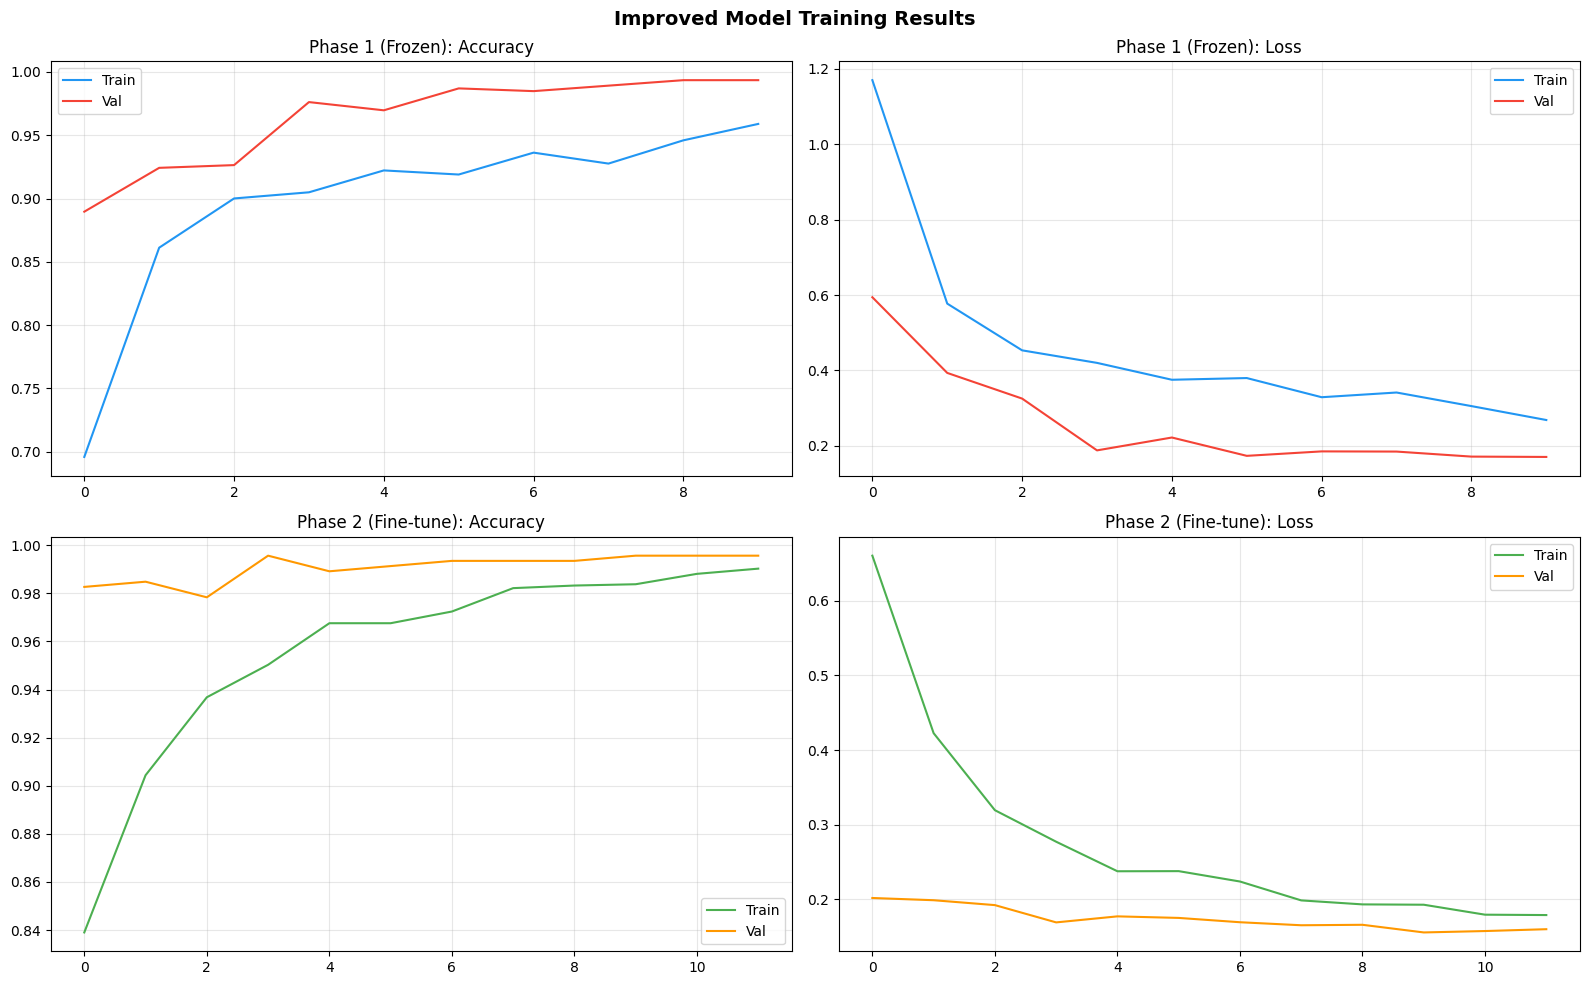

Saved: /content/drive/MyDrive/MedicinalPlant_Dissertation/improved_training_curves.png


In [ ]:
# Re-establish paths if runtime was restarted
try:
    PROJECT_DIR
except NameError:
    DRIVE_BASE = "/content/drive/MyDrive"
    PROJECT_DIR = os.path.join(DRIVE_BASE, "MedicinalPlant_Dissertation")
    MODEL_DIR = os.path.join(PROJECT_DIR, "models")

# Try in-memory history first, fall back to saved JSON
try:
    p1_acc = history_p1.history['accuracy']
    p1_val_acc = history_p1.history['val_accuracy']
    p1_loss = history_p1.history['loss']
    p1_val_loss = history_p1.history['val_loss']
    p2_acc = history_p2.history['accuracy']
    p2_val_acc = history_p2.history['val_accuracy']
    p2_loss = history_p2.history['loss']
    p2_val_loss = history_p2.history['val_loss']
except NameError:
    print(">>> Training history not in memory, loading from saved file...")
    history_path = os.path.join(MODEL_DIR, "improved_history.json")
    with open(history_path, 'r') as f:
        hist = json.load(f)
    p1_acc = hist['p1_accuracy']
    p1_val_acc = hist['p1_val_accuracy']
    p1_loss = hist['p1_loss']
    p1_val_loss = hist['p1_val_loss']
    p2_acc = hist['p2_accuracy']
    p2_val_acc = hist['p2_val_accuracy']
    p2_loss = hist['p2_loss']
    p2_val_loss = hist['p2_val_loss']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Improved Model Training Results", fontsize=14, fontweight='bold')

axes[0][0].plot(p1_acc, label='Train', color='#2196F3')
axes[0][0].plot(p1_val_acc, label='Val', color='#F44336')
axes[0][0].set_title('Phase 1 (Frozen): Accuracy')
axes[0][0].legend()
axes[0][0].grid(True, alpha=0.3)

axes[0][1].plot(p1_loss, label='Train', color='#2196F3')
axes[0][1].plot(p1_val_loss, label='Val', color='#F44336')
axes[0][1].set_title('Phase 1 (Frozen): Loss')
axes[0][1].legend()
axes[0][1].grid(True, alpha=0.3)

axes[1][0].plot(p2_acc, label='Train', color='#4CAF50')
axes[1][0].plot(p2_val_acc, label='Val', color='#FF9800')
axes[1][0].set_title('Phase 2 (Fine-tune): Accuracy')
axes[1][0].legend()
axes[1][0].grid(True, alpha=0.3)

axes[1][1].plot(p2_loss, label='Train', color='#4CAF50')
axes[1][1].plot(p2_val_loss, label='Val', color='#FF9800')
axes[1][1].set_title('Phase 2 (Fine-tune): Loss')
axes[1][1].legend()
axes[1][1].grid(True, alpha=0.3)

plt.tight_layout()
curves_path = os.path.join(PROJECT_DIR, "improved_training_curves.png")
plt.savefig(curves_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {curves_path}")

## Recovery (run if runtime was restarted)

If the Colab runtime disconnected or restarted after training completed, run:
1. Cell 1 (Mount Google Drive)
2. Cell 2 (Imports)
3. Then run the cell below to reload model + dataset from Drive

If you ran all cells top-to-bottom without interruption, skip this cell.

In [ ]:
# Run this cell if Colab runtime was restarted after training completed.
# First re-run Cell 1 (Mount Drive) and Cell 2 (Imports), then run this cell.

print(">>> Checking if recovery is needed...")

recovery_needed = False
for _var_name in ['val_dataset', 'model', 'class_names', 'MODEL_DIR']:
    try:
        eval(_var_name)
    except NameError:
        recovery_needed = True
        break

if not recovery_needed:
    print(">>> All variables present - no recovery needed, skip to Evaluation")
else:
    print(">>> Variables missing - recovering from saved files on Drive...\n")

    # Re-establish paths
    DRIVE_BASE = "/content/drive/MyDrive"
    PROJECT_DIR = os.path.join(DRIVE_BASE, "MedicinalPlant_Dissertation")
    DATA_DIR = os.path.join(PROJECT_DIR, "data")
    MODEL_DIR = os.path.join(PROJECT_DIR, "models")
    IMG_SIZE = (300, 300)
    BATCH_SIZE = 16
    SEED = 42
    DROP_CLASSES = ['Trifolium Repens', 'Trifolium_Repens', 'Ziziphus mauritiana', 'Ziziphus_mauritiana']

    # Load class names
    class_names_path = os.path.join(MODEL_DIR, "improved_class_names.json")
    with open(class_names_path, 'r') as f:
        class_names = json.load(f)
    NUM_CLASSES = len(class_names)
    print(f"  Loaded {NUM_CLASSES} class names")

    # Reload saved model
    model_save_path = os.path.join(MODEL_DIR, "improved_model.keras")
    model = keras.models.load_model(model_save_path)
    print(f"  Loaded model from Drive")

    # Find dataset on Drive
    def find_image_directory(base_dir):
        if not os.path.exists(base_dir):
            return None
        for root, dirs, files in os.walk(base_dir):
            dirs[:] = [d for d in dirs if not d.startswith('.')]
            if not dirs:
                continue
            sample_dir = os.path.join(root, dirs[0])
            if os.path.isdir(sample_dir):
                sample_files = os.listdir(sample_dir)
                if any(f.lower().endswith(('.jpg', '.jpeg', '.png')) for f in sample_files):
                    return root
        return None

    dataset_path = None
    for p in [os.path.join(DATA_DIR, "dataset5"), os.path.join(DATA_DIR, "Dataset 5"),
              os.path.join(DATA_DIR, "SIMPD"), os.path.join(DATA_DIR, "dataset5_commercial")]:
        if os.path.exists(p):
            found = find_image_directory(p)
            if found:
                dataset_path = found
                break
    if dataset_path is None:
        dataset_path = find_image_directory(DATA_DIR)
    if dataset_path is None:
        raise FileNotFoundError("Could not find Dataset 5 on Drive!")

    # Filter dropped classes
    all_classes = sorted([d for d in os.listdir(dataset_path)
                          if os.path.isdir(os.path.join(dataset_path, d)) and not d.startswith('.')])
    keep_classes = [c for c in all_classes if c not in DROP_CLASSES]
    if len(keep_classes) < len(all_classes):
        filtered_path = "/content/filtered_dataset"
        if os.path.exists(filtered_path):
            shutil.rmtree(filtered_path)
        os.makedirs(filtered_path)
        for c in keep_classes:
            shutil.copytree(os.path.join(dataset_path, c), os.path.join(filtered_path, c))
        dataset_path = filtered_path

    # Create validation dataset
    val_dataset = tf.keras.utils.image_dataset_from_directory(
        dataset_path, validation_split=0.2, subset="validation",
        seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
        label_mode="categorical", shuffle=False
    )
    val_dataset = val_dataset.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
    print(f"  Validation dataset loaded from: {dataset_path}")

    print("\n>>> Recovery complete! Now run the Evaluation cell below.")

## Detailed evaluation

In [ ]:
print("\n" + "="*60)
print("EVALUATION")
print("="*60)

# Check required variables exist (run Recovery cell above if this fails)
try:
    val_dataset, model, class_names
except NameError as e:
    raise RuntimeError(
        f"Missing variable: {e}\n"
        "If runtime was restarted after training, run these cells first:\n"
        "  1. Cell 1 (Mount Drive)\n"
        "  2. Cell 2 (Imports)\n"
        "  3. Recovery cell (above this section)"
    )

# Re-establish paths if needed
try:
    MODEL_DIR
except NameError:
    DRIVE_BASE = "/content/drive/MyDrive"
    PROJECT_DIR = os.path.join(DRIVE_BASE, "MedicinalPlant_Dissertation")
    MODEL_DIR = os.path.join(PROJECT_DIR, "models")

# Get predictions on validation set
y_pred = []
y_true = []
for images, labels in val_dataset:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_pred = np.array(y_pred)
y_true = np.array(y_true)

# Overall accuracy
overall_acc = np.mean(y_pred == y_true)
print(f"\n>>> Overall Accuracy: {overall_acc*100:.1f}%")

# Classification report - use labels param to include all classes
all_labels = list(range(len(class_names)))
print("\nPer-Species Classification Report:")
print("=" * 80)
report = classification_report(y_true, y_pred, labels=all_labels, target_names=class_names, output_dict=True, zero_division=0)
report_text = classification_report(y_true, y_pred, labels=all_labels, target_names=class_names, zero_division=0)
print(report_text)

# Save metrics
metrics_path = os.path.join(MODEL_DIR, "improved_species_metrics.json")
with open(metrics_path, 'w') as f:
    json.dump(report, f, indent=2)
print(f"\nSaved metrics: {metrics_path}")

# Confusion matrix - use labels param to include all classes
cm = confusion_matrix(y_true, y_pred, labels=all_labels)
plt.figure(figsize=(14, 11))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Improved Model Confusion Matrix (Accuracy: {overall_acc*100:.1f}%)',
          fontsize=13, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
cm_path = os.path.join(PROJECT_DIR, "improved_confusion_matrix.png")
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {cm_path}")


EVALUATION

>>> Overall Accuracy: 99.6%

Per-Species Classification Report:


ValueError: Number of classes, 7, does not match size of target_names, 18. Try specifying the labels parameter

## Comparison with old model

In [ ]:
print("\n" + "="*60)
print("COMPARISON: Old vs Improved Model")
print("="*60)

# Re-establish paths if needed
try:
    MODEL_DIR
except NameError:
    DRIVE_BASE = "/content/drive/MyDrive"
    PROJECT_DIR = os.path.join(DRIVE_BASE, "MedicinalPlant_Dissertation")
    MODEL_DIR = os.path.join(PROJECT_DIR, "models")

old_metrics_path = os.path.join(MODEL_DIR, "phase3b_species_metrics.json")
if os.path.exists(old_metrics_path):
    with open(old_metrics_path, 'r') as f:
        old_metrics = json.load(f)
    old_acc = old_metrics.get('accuracy', 0)
    print(f"\n  Old model accuracy:      {old_acc*100:.1f}%")
    print(f"  Improved model accuracy: {overall_acc*100:.1f}%")
    print(f"  Improvement:             {(overall_acc - old_acc)*100:+.1f}%")

    # Per-species comparison
    print(f"\n  {'Species':35s} {'Old F1':>8s} {'New F1':>8s} {'Change':>8s}")
    print("  " + "-" * 60)
    for c in class_names:
        old_f1 = old_metrics.get(c, {}).get('f1-score', 0)
        new_f1 = report.get(c, {}).get('f1-score', 0)
        change = new_f1 - old_f1
        marker = "+" if change > 0 else "-" if change < 0 else " "
        print(f"  {c:35s} {old_f1*100:7.1f}% {new_f1*100:7.1f}% {change*100:+7.1f}% {marker}")
else:
    print("  (Old metrics not found for comparison)")
    print(f"\n  Improved model accuracy: {overall_acc*100:.1f}%")

## Summary & Download


In [ ]:
print("\n" + "="*60)
print("SUMMARY")
print("="*60)

# Re-establish paths if needed
try:
    model_save_path
except NameError:
    DRIVE_BASE = "/content/drive/MyDrive"
    PROJECT_DIR = os.path.join(DRIVE_BASE, "MedicinalPlant_Dissertation")
    MODEL_DIR = os.path.join(PROJECT_DIR, "models")
    model_save_path = os.path.join(MODEL_DIR, "improved_model.keras")
    class_names_path = os.path.join(MODEL_DIR, "improved_class_names.json")
    metrics_path = os.path.join(MODEL_DIR, "improved_species_metrics.json")

print(f"\nModel saved to Google Drive:")
print(f"  Model: {model_save_path}")
print(f"  Classes: {class_names_path}")
print(f"  Metrics: {metrics_path}")

# Download model files
try:
    from google.colab import files
    print("\nDownloading model files...")
    files.download(model_save_path)
    files.download(class_names_path)
    files.download(metrics_path)
except:
    print("\n(Download manually from Google Drive)")

print("\n>>> TRAINING COMPLETE! <<<")